In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

path = "../data/silver/"

In [88]:
orders = pd.read_parquet(f'{path}orders.parquet')
items = pd.read_parquet(f'{path}order_items.parquet')
payments = pd.read_parquet(f'{path}order_payments.parquet')
customers = pd.read_parquet(f'{path}customers.parquet')
products = pd.read_parquet(f'{path}products.parquet') 

#### Qual o valor gasto por pedido e como ele varia?

Ticket médio por pedido: R$ 137.75
Desvio padrão: R$ 210.65


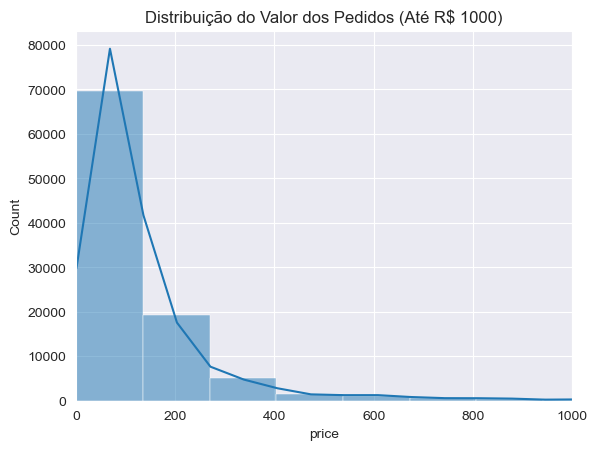

In [16]:
venda_por_pedido = items.groupby("order_id")["price"].sum().reset_index()

mean_ticket = venda_por_pedido["price"].mean()
std_ticket = venda_por_pedido["price"].std()

print(f"Ticket médio por pedido: R$ {mean_ticket:.2f}")
print(f"Desvio padrão: R$ {std_ticket:.2f}")

sns.histplot(venda_por_pedido["price"], bins=100, kde=True)
plt.xlim(0, 1000) 
plt.title("Distribuição do Valor dos Pedidos (Até R$ 1000)")
plt.show()

#### Quais os 5 estados que geram mais receita?

Top 5 Estados por Receita:
customer_state
SP    5202955.05
RJ    1824092.67
MG    1585308.03
RS     750304.02
PR     683083.76
Name: price, dtype: float64


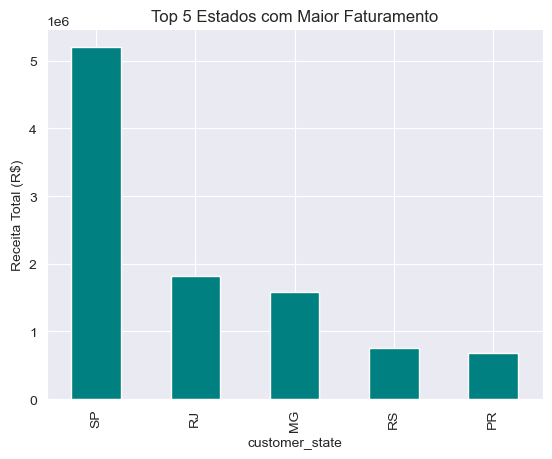

In [17]:
df_receita = items.merge(orders, on='order_id').merge(customers, on='customer_id')

receita_estado = df_receita.groupby('customer_state')['price'].sum().sort_values(ascending=False).head(5)

print("Top 5 Estados por Receita:")
print(receita_estado)

receita_estado.plot(kind='bar', color='teal')
plt.ylabel("Receita Total (R$)")
plt.title("Top 5 Estados com Maior Faturamento")
plt.show()

#### Frete vs cancelamento

is_canceled
False    19.991964
True     19.650277
Name: freight_value, dtype: float64


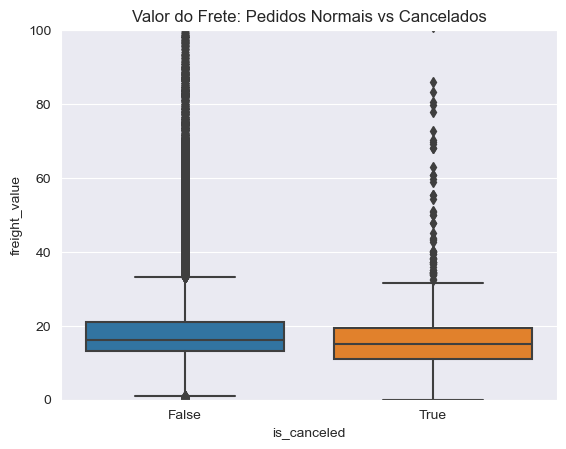

In [10]:
# Criamos uma coluna booleana para cancelados
orders['is_canceled'] = orders['order_status'] == 'canceled'

# Join com itens para pegar o valor do frete
df_frete = orders.merge(items[['order_id', 'freight_value']], on='order_id')

# Comparação de médias
print(df_frete.groupby('is_canceled')['freight_value'].mean())

sns.boxplot(data=df_frete, x='is_canceled', y='freight_value')
plt.ylim(0, 100) # Focando na maioria dos dados
plt.title("Valor do Frete: Pedidos Normais vs Cancelados")
plt.show()

#### Cartão de Crédito vs Outros

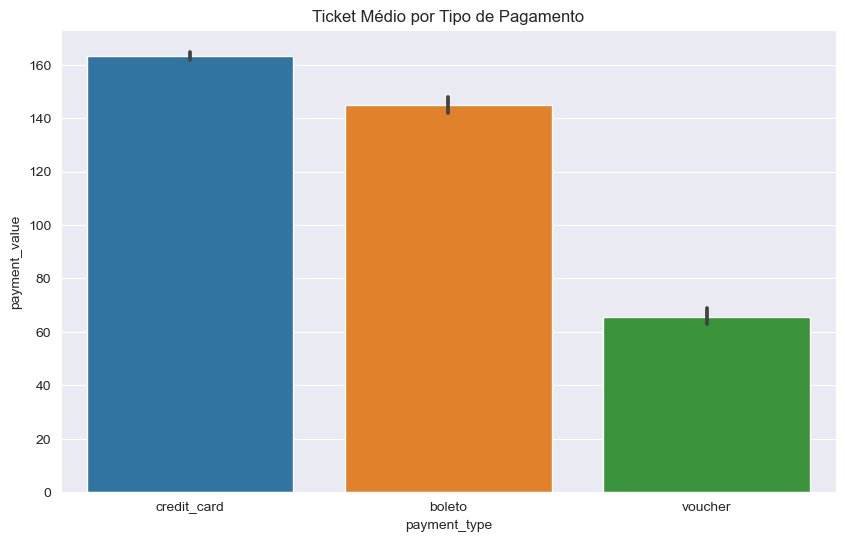

Diferença CC vs Boleto: R$ 18.28


In [11]:
# Filtrando apenas os principais tipos
top_payments = payments[payments['payment_type'].isin(['credit_card', 'boleto', 'voucher'])]

plt.figure(figsize=(10,6))
sns.barplot(data=top_payments, x='payment_type', y='payment_value', estimator=np.mean)
plt.title("Ticket Médio por Tipo de Pagamento")
plt.show()

media_cc = top_payments[top_payments['payment_type'] == 'credit_card']['payment_value'].mean()
media_boleto = top_payments[top_payments['payment_type'] == 'boleto']['payment_value'].mean()
print(f"Diferença CC vs Boleto: R$ {media_cc - media_boleto:.2f}")

#### Capitais vs interior

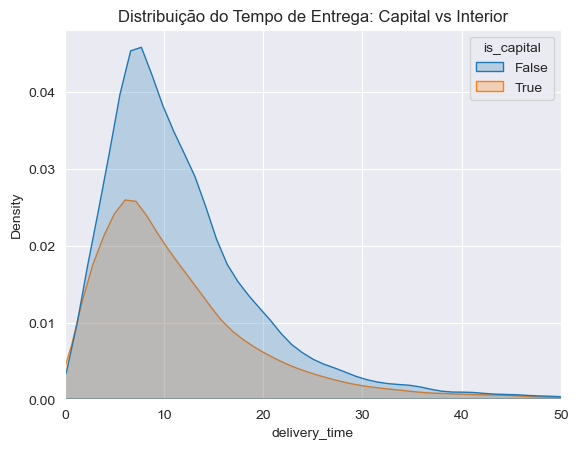

is_capital
False    12.256840
True     11.823612
Name: delivery_time, dtype: float64


In [12]:
capitais = [
    'sao paulo', 'rio de janeiro', 'belo horizonte', 'vitoria', 'curitiba', 'florianopolis', 
    'porto alegre', 'salvador', 'recife', 'fortaleza', 'natal', 'joao pessoa', 'maceio', 
    'aracaju', 'teresina', 'sao luis', 'belem', 'manaus', 'porto velho', 'rio branco', 
    'macapa', 'boa vista', 'palmas', 'cuiaba', 'campo grande', 'goiania', 'brasilia'
]

# Marcar se é capital ou não
customers['is_capital'] = customers['customer_city'].str.lower().isin(capitais)

# Calculando tempo de entrega
orders['delivery_time'] = (orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']).dt.days

df_entrega = orders.merge(customers[['customer_id', 'is_capital']], on='customer_id')

# Remover nulos (pedidos não entregues ainda)
df_entrega = df_entrega.dropna(subset=['delivery_time'])

sns.kdeplot(data=df_entrega, x='delivery_time', hue='is_capital', fill=True)
plt.xlim(0, 50)
plt.title("Distribuição do Tempo de Entrega: Capital vs Interior")
plt.show()

print(df_entrega.groupby('is_capital')['delivery_time'].mean())

In [18]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [20]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [22]:
#pd.merge(orders, customers, on='customer_id', how='left').head()


## tipos de pagamentos por cidade

payments.head()





,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [40]:
## are there any orders with different payment types?

### select orders and count their unique payment types
payments_consistency = payments.groupby('order_id')['payment_type'].nunique()

### filter orders with more than 1 payment type
invalid_orders = payments_consistency[payments_consistency > 1].index.tolist()

if invalid_orders:
    print(f"⚠️ Atenção: As seguintes ordens possuem tipos de pagamento mistos: {invalid_orders}")
    df_errors = payments[payments['order_id'].isin(invalid_orders)]
    print(df_errors)

⚠️ Atenção: As seguintes ordens possuem tipos de pagamento mistos: ['0016dfedd97fc2950e388d2971d718c7', '009ac365164f8e06f59d18a08045f6c4', '00b4a910f64f24dbcac04fe54088a443', '00bd50cdd31bd22e9081e6e2d5b3577b', '00c405bd71187154a7846862f585a9d4', '00c95282163553a982f38481f9488481', '00e6bc6b166eb28b4502c1cad4457248', '013037c3f1773cc8fdbaf8ff54d8013b', '0218c7a4fb8d5b1bd22c82b783b8359c', '02725851051698269253f0823e7824b6', '028369515408fa864cfe50091d4e76c5', '02dbd29bc7a490d582762fae9f0fd997', '02ec4da9d03014f06d711d60eb37cc22', '033a7061d514534d3459c3f1f06fe341', '035678e70978296fb0e7469a611c322e', '035ab6fc3b7f9d16f714a337ee63b7be', '0392bc239ce28b0377e6b3073df2c674', '039f61edec89c6f0edf8dd1a0bdea1fe', '03a10721769c7d8f2fefab105e64fbef', '03c968d10d8c63bd2388245d02579fde', '03ecec245220b63fd7f68c1737ba99ba', '03f51c9adce893f63936c5146701aa2f', '0420dbc50fc554e303e4b2d6b39063f6', '042649285cd08ef7c546445419b43407', '0484f1d11d891ff86fcc2d225ce7094e', '04915529f622f4b069fb4501085fd90

In [57]:
## Most sold product category by

orders.query("order_id == '0008288aa423d2a3f00fcb17cd7d8719'")

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
53957,0008288aa423d2a3f00fcb17cd7d8719,2355af7c75e7c98b43a87b2a7f210dc5,delivered,2018-02-13 22:10:21,2018-02-15 03:55:52,2018-02-20 18:23:28,2018-02-26 13:55:22,2018-03-06


In [61]:
payments.query("order_id == '0008288aa423d2a3f00fcb17cd7d8719'")

,order_id,payment_sequential,payment_type,payment_installments,payment_value


In [63]:
## duplicated customers check

# 1. Localizar todos os registros que possuem IDs duplicados
# O parâmetro keep=False garante que você veja TODAS as ocorrências do ID repetido, 
# não apenas a segunda ou a última.
duplicados = customers[customers.duplicated(subset=['customer_id'], keep=False)]

# 2. Ordenar para facilitar a comparação visual no Jupyter
duplicados_ordenados = duplicados.sort_values(by='customer_id')

if not duplicados_ordenados.empty:
    print(f"⚠️ Encontrados {duplicados_ordenados['customer_id'].nunique()} IDs de clientes duplicados.")
    display(duplicados_ordenados.head(10))
else:
    print("✅ Nenhum ID duplicado encontrado.")

✅ Nenhum ID duplicado encontrado.


In [64]:
customers.columns.tolist()

['customer_id',
 'customer_unique_id',
 'customer_zip_code_prefix',
 'customer_city',
 'customer_state']

In [67]:
#len(customers['customer_unique_id'].unique())
len(customers['customer_unique_id'])

99441

## Itens a reportar
- unique id dos customers. enderecos moviso pra tabela de ordens;
- alteracoes na tabela de ordens
    - 
- 

In [68]:
orders.columns.tolist()

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date']

In [86]:
# testing merge orders with customers
print(len(orders))
print(len(customers))

address_lookup = customers[[
    'customer_id',
    'customer_zip_code_prefix', 
    'customer_city',
    'customer_state']]

enriched = pd.merge(orders, customers, on='customer_id', how='left')
len(enriched)
enriched.head()

# enrich order with total value

df_items_sum = items.groupby('order_id')['price'].sum().reset_index()
df_items_sum = df_items_sum.rename(columns={'price': 'total_price'})

df_freight_sum = items.groupby('order_id')['freight_value'].sum().reset_index()
df_freight_sum = df_freight_sum.rename(columns={'freight_value': 'total_freight'}) 

enriched = pd.merge(enriched, df_items_sum, on='order_id', how='left')
enriched = pd.merge(enriched, df_freight_sum, on='order_id', how='left')

enriched.head()

99441
99441


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,total_price,total_freight
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,19.90,8.72


In [89]:
print(items.columns.tolist())
print(products.columns.tolist())

products.columns.tolist()

['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']
['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']


['product_id',
 'product_category_name',
 'product_name_lenght',
 'product_description_lenght',
 'product_photos_qty',
 'product_weight_g',
 'product_length_cm',
 'product_height_cm',
 'product_width_cm']